In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# dataset load
df = pd.read_csv("medical_insurance.csv")

# preview data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
def Desc_stat(ds, var):
    mean = ds[var].mean()
    median = ds[var].median()
    mode = ds[var].mode().iloc[0] if not ds[var].mode().empty else None
    minimum = ds[var].min()
    maximum = ds[var].max()
    rng = maximum - minimum
    std_dev = ds[var].std()
    variance = ds[var].var()
    skew = ds[var].skew()
    kurtosis = ds[var].kurt()
    q1 = ds[var].quantile(0.25)
    q2 = ds[var].quantile(0.50)
    q3 = ds[var].quantile(0.75)
    iqr = q3 - q1
    count = ds[var].count()

    return {
      "Count": count,
        "Mean": mean,
        "Median": median,
        "Mode": ds[var].mode().iloc[0] if not ds[var].mode().empty else None,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": maximum - minimum,
        "Std Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "25th Percentile (Q1)": q1,
        "50th Percentile (Q2)": q2,
        "75th Percentile (Q3)": q3,
        "IQR": iqr
}

In [4]:
#Random sample
random_sample = df.sample(n=150, random_state=42)
print("Random sample size:", len(random_sample))
Desc_stat(random_sample, "charges")

Random sample size: 150


{'Count': np.int64(150),
 'Mean': np.float64(12917.854539066668),
 'Median': 9041.6135,
 'Mode': np.float64(1163.4627),
 'Minimum': 1121.8739,
 'Maximum': 63770.42801,
 'Range': 62648.554110000005,
 'Std Deviation': 12776.675482168685,
 'Variance': 163243436.3766504,
 'Skewness': np.float64(1.7612174480121165),
 'Kurtosis': np.float64(2.9063471475950022),
 '25th Percentile (Q1)': np.float64(3817.9505),
 '50th Percentile (Q2)': np.float64(9041.6135),
 '75th Percentile (Q3)': np.float64(16514.3347825),
 'IQR': np.float64(12696.3842825)}

In [5]:
#Systematic sample
df_cond = df[df["age"] > 30]
systematic_sample = df_cond.iloc[::5].head(150)

print("Systematic sample size:", len(systematic_sample))
Desc_stat(systematic_sample, "charges")

Systematic sample size: 150


{'Count': np.int64(150),
 'Mean': np.float64(14891.766926199998),
 'Median': 10658.014500000001,
 'Mode': np.float64(3260.199),
 'Minimum': 3260.199,
 'Maximum': 48885.13561,
 'Range': 45624.93661,
 'Std Deviation': 11100.354895899774,
 'Variance': 123217878.81492607,
 'Skewness': np.float64(1.6137843417047595),
 'Kurtosis': np.float64(1.6632612680327759),
 '25th Percentile (Q1)': np.float64(7802.8356125),
 '50th Percentile (Q2)': np.float64(10658.014500000001),
 '75th Percentile (Q3)': np.float64(15844.3308125),
 'IQR': np.float64(8041.4952)}

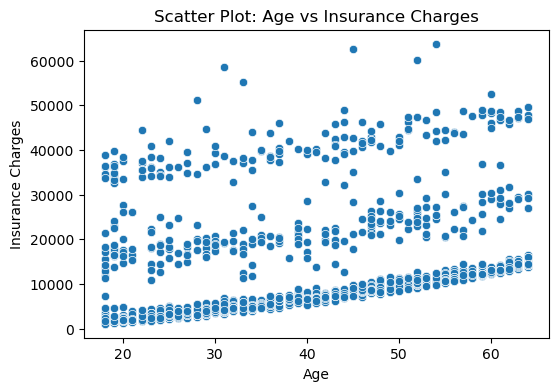

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Scatter Plot: Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()


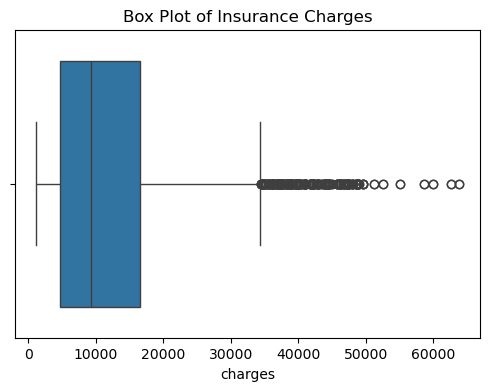

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['charges'])
plt.title("Box Plot of Insurance Charges")
plt.show()


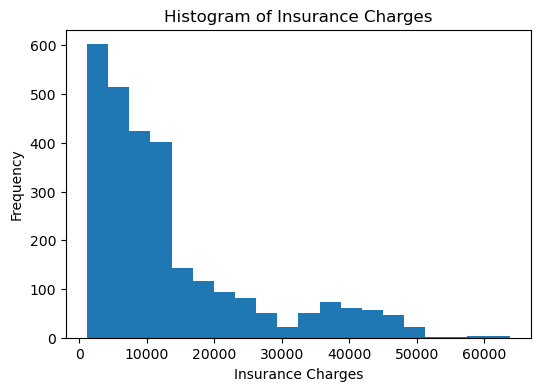

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df['charges'], bins=20)
plt.title("Histogram of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")
plt.show()


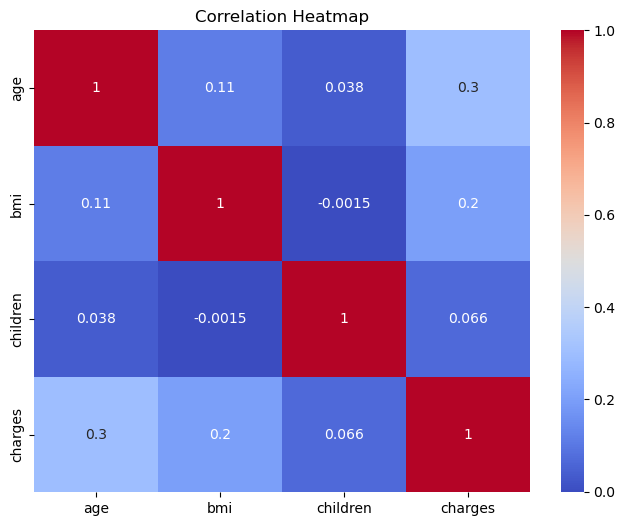

In [9]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()


In [10]:
from scipy.stats import pearsonr

alpha = 0.05

# Pearson test
r1, p1 = pearsonr(df['age'], df['charges'])

print("----- Pearson Correlation -----")
print("Pearson r =", r1)
print("p-value =", p1)

if p1 < alpha:
    print("Decision: Reject H0 (significant relationship)")
else:
    print("Decision: Fail to reject H0 (no significant relationship)")

----- Pearson Correlation -----
Pearson r = 0.2986236656293628
p-value = 3.316072999833239e-58
Decision: Reject H0 (significant relationship)


In [11]:
from scipy.stats import spearmanr

alpha = 0.05

# Spearman test
r2, p2 = spearmanr(df['age'], df['charges'])

print("----- Spearman Correlation -----")
print("Spearman r =", r2)
print("p-value =", p2)

if p2 < alpha:
    print("Decision: Reject H0 (significant relationship)")
else:
    print("Decision: Fail to reject H0 (no significant relationship)")

----- Spearman Correlation -----
Spearman r = 0.5358797599935969
p-value = 6.905661241953329e-206
Decision: Reject H0 (significant relationship)


In [12]:
from scipy.stats import chi2_contingency
import pandas as pd


table = pd.crosstab(df['smoker'], df['region'])

# chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("----- Chi-square Correlation -----")
print("Chi-square value:", chi2)
print("p-value:", p)


if p < 0.05:
    print("Decision: Reject H0 (significant relationship)")
else:
    print("Decision: Fail to reject H0 (no significant relationship)")

----- Chi-square Correlation -----
Chi-square value: 17.326940977933212
p-value: 0.0006053262237744672
Decision: Reject H0 (significant relationship)


In [13]:
from scipy.stats import ttest_1samp

pop_mean = df['charges'].mean()

sample = df.sample(n=150, random_state=42)

t_stat, p = ttest_1samp(sample['charges'], pop_mean)

print("t-value:", t_stat)
print("p-value:", p)

if p < 0.05:
    print("Decision: Reject H0 (significant relationship)")
else:
    print("Decision: Fail to reject H0 (no significant relationship)")

t-value: -0.3292865577214313
p-value: 0.7424015175764549
Decision: Fail to reject H0 (no significant relationship)


In [14]:
df.columns
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dataset load
df = pd.read_csv("medical_insurance.csv")

# preview data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [19]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

from sklearn.preprocessing import LabelEncoder

def smoker_category(x):
    if x == "yes":
        return "Smoker"
    else:
        return "Non-Smoker"

#function
df["Smoker_Category"] = df["smoker"].apply(smoker_category)

print(df[["smoker", "Smoker_Category"]].head())


le = LabelEncoder()
df["Smoker_Encoded"] = le.fit_transform(df["Smoker_Category"])

print(df[["smoker", "Smoker_Category", "Smoker_Encoded"]].head())

  smoker Smoker_Category
0    yes          Smoker
1     no      Non-Smoker
2     no      Non-Smoker
3     no      Non-Smoker
4     no      Non-Smoker
  smoker Smoker_Category  Smoker_Encoded
0    yes          Smoker               1
1     no      Non-Smoker               0
2     no      Non-Smoker               0
3     no      Non-Smoker               0
4     no      Non-Smoker               0


In [20]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
df[['charges']].head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [23]:
import numpy as np

numeric_features = ['age', 'bmi', 'children', 'charges']

outlier_rows = set()

for col in numeric_features:
    
    first_q = df_encoded[col].quantile(0.25)
    third_q = df_encoded[col].quantile(0.75)
    
    spread = third_q - first_q
    
    lower_bound = first_q - 1.5 * spread
    upper_bound = third_q + 1.5 * spread
    
    mask = (df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)
    
    outlier_rows.update(df_encoded[mask].index)

# total outliers print 
print("Outliers found:", len(outlier_rows))

clean_data = df_encoded.drop(index=outlier_rows)

print("Dataset size before cleaning:", df_encoded.shape)
print("Dataset size after cleaning:", clean_data.shape)

Outliers found: 145
Dataset size before cleaning: (1337, 9)
Dataset size after cleaning: (1192, 9)


In [24]:
from sklearn.model_selection import train_test_split

X = clean_data.drop('charges', axis=1)

y = clean_data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# verify
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (953, 8)
Testing data shape: (239, 8)


In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures

# ---Linear Regression---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
pred_lin = lin_reg.predict(X_test)

# ---Polynomial Regression---
poly_transform = PolynomialFeatures(degree=2)

X_train_poly = poly_transform.fit_transform(X_train)
X_test_poly = poly_transform.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
pred_poly = poly_reg.predict(X_test_poly)

# ---Ridge Regression---
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
pred_ridge = ridge_reg.predict(X_test)

# ---Lasso Regression---
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)
pred_lasso = lasso_reg.predict(X_test)

# ---Elastic Net----
elastic_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_reg.fit(X_train, y_train)
pred_elastic = elastic_reg.predict(X_test)

print("All Regression models trained successfully")

All Regression models trained successfully


In [26]:
X_train_poly.shape

(953, 45)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

model_list = []
mse_list = []
r2_list = []

# Linear
model_list.append("Linear")
mse_list.append(mean_squared_error(y_test, pred_lin))
r2_list.append(r2_score(y_test, pred_lin))

# Polynomial
model_list.append("Polynomial")
mse_list.append(mean_squared_error(y_test, pred_poly))
r2_list.append(r2_score(y_test, pred_poly))

# Ridge
model_list.append("Ridge")
mse_list.append(mean_squared_error(y_test, pred_ridge))
r2_list.append(r2_score(y_test, pred_ridge))

# Lasso
model_list.append("Lasso")
mse_list.append(mean_squared_error(y_test, pred_lasso))
r2_list.append(r2_score(y_test, pred_lasso))

# Elastic Net
model_list.append("ElasticNet")
mse_list.append(mean_squared_error(y_test, pred_elastic))
r2_list.append(r2_score(y_test, pred_elastic))

evaluation_results = pd.DataFrame({
    "Model": model_list,
    "MSE": mse_list,
    "R2 Score": r2_list
})

evaluation_results

,Model,MSE,R2 Score
0,Linear,2.535898e+07,0.536710
1,Polynomial,2.411830e+07,0.559376
2,Ridge,2.533762e+07,0.537100
3,Lasso,2.535831e+07,0.536722
4,ElasticNet,2.694580e+07,0.507719


In [28]:
best_index = evaluation_results["R2 Score"].idxmax()

best_model_name = evaluation_results.loc[best_index, "Model"]
best_r2_value = evaluation_results.loc[best_index, "R2 Score"]

print("Best Model:", best_model_name)
print("Best R2 Score:", best_r2_value)

Best Model: Polynomial
Best R2 Score: 0.559375784134891


In [29]:
print("Polynomial Model Equation:")

poly_b = poly_reg.intercept_
poly_w = poly_reg.coef_

poly_names = poly_transform.get_feature_names_out(X.columns)

poly_formula = "Charges = " + str(round(poly_b, 3))

for idx in range(len(poly_w)):
    term_value = round(poly_w[idx], 3)
    term_name = poly_names[idx]
    poly_formula += " + (" + str(term_value) + " * " + term_name + ")"

print(poly_formula)

Polynomial Model Equation:
Charges = -1125.424 + (0.0 * 1) + (-18.285 * age) + (179.323 * bmi) + (1088.227 * children) + (-123.674 * sex_male) + (-1927.37 * smoker_yes) + (1184.336 * region_northwest) + (1100.279 * region_southeast) + (665.173 * region_southwest) + (4.239 * age^2) + (-2.835 * age bmi) + (1.151 * age children) + (7.929 * age sex_male) + (-117.863 * age smoker_yes) + (20.431 * age region_northwest) + (43.332 * age region_southeast) + (25.023 * age region_southwest) + (1.175 * bmi^2) + (1.783 * bmi children) + (-27.556 * bmi sex_male) + (896.698 * bmi smoker_yes) + (-148.234 * bmi region_northwest) + (-169.599 * bmi region_southeast) + (-117.681 * bmi region_southwest) + (-117.014 * children^2) + (205.112 * children sex_male) + (-190.672 * children smoker_yes) + (225.732 * children region_northwest) + (-324.127 * children region_southeast) + (-550.775 * children region_southwest) + (-123.674 * sex_male^2) + (-1288.091 * sex_male smoker_yes) + (253.662 * sex_male region_no

In [30]:
print("Linear Model Equation:")

lin_b = lin_reg.intercept_
lin_w = lin_reg.coef_

lin_formula = "Charges = " + str(round(lin_b, 3))

for idx in range(len(lin_w)):
    coef_val = round(lin_w[idx], 3)
    feature_name = X.columns[idx]
    lin_formula += " + (" + str(coef_val) + " * " + feature_name + ")"

print(lin_formula)

Linear Model Equation:
Charges = -3056.196 + (241.676 * age) + (78.295 * bmi) + (419.361 * children) + (-463.771 * sex_male) + (14784.084 * smoker_yes) + (-391.387 * region_northwest) + (-1369.829 * region_southeast) + (-1328.814 * region_southwest)


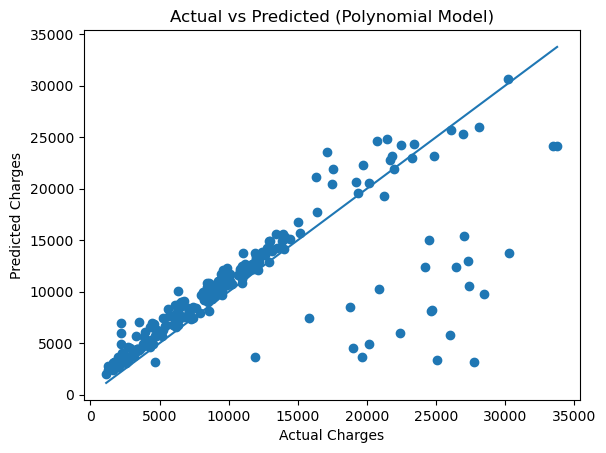

In [31]:
import matplotlib.pyplot as plt

# actual and predicted values (polynomial model)
real_vals = y_test
pred_vals = pred_poly

plt.figure()


plt.scatter(real_vals, pred_vals)

start_val = min(real_vals.min(), pred_vals.min())
end_val = max(real_vals.max(), pred_vals.max())

plt.plot([start_val, end_val], [start_val, end_val])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Polynomial Model)")

plt.show()

In [32]:
# target variable ko categorical banana
threshold = df['charges'].mean()

df['charge_category'] = df['charges'].apply(lambda x: 'High' if x > threshold else 'Low')

In [33]:
X = df_encoded.drop(['charges'], axis=1)
y = df['charge_category']

In [34]:
df['charge_category'] = df['charges'].apply(
    lambda x: 'High' if x > df['charges'].mean() else 'Low'
)

df[['charges','charge_category']].head()

,charges,charge_category
0,16884.92400,High
1,1725.55230,Low
2,4449.46200,Low
3,21984.47061,High
4,3866.85520,Low


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


df_encoded = pd.get_dummies(df, drop_first=True)

# features & target (fixed)
X = df_encoded.drop(columns=['charges'], errors='ignore')
y = df['charge_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label='High')
    rec = recall_score(y_test, preds, pos_label='High')
    f1 = f1_score(y_test, preds, pos_label='High')
    
    cm = confusion_matrix(y_test, preds)
    
    error = cm[0][1] + cm[1][0]
    
    results.append([name, cm, error, acc, prec, rec, f1])

classification_results = pd.DataFrame(results, columns=[
    "Model","Confusion Matrix","Errors","Accuracy","Precision","Recall","F1 Score"
])

classification_results

,Model,Confusion Matrix,Errors,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,"[[86, 0], [0, 182]]",0,1.000000,1.000000,1.000000,1.000000
1,KNN,"[[48, 38], [8, 174]]",46,0.828358,0.857143,0.558140,0.676056
2,SVM,"[[4, 82], [0, 182]]",82,0.694030,1.000000,0.046512,0.088889
3,Decision Tree,"[[86, 0], [0, 182]]",0,1.000000,1.000000,1.000000,1.000000
4,Random Forest,"[[86, 0], [0, 182]]",0,1.000000,1.000000,1.000000,1.000000


In [36]:
best_index = classification_results['Accuracy'].idxmax()
classification_results.loc[best_index]

Model               Logistic Regression
Confusion Matrix    [[86, 0], [0, 182]]
Errors                                0
Accuracy                            1.0
Precision                           1.0
Recall                              1.0
F1 Score                            1.0
Name: 0, dtype: object

In [37]:
df['charge_category'].value_counts()

charge_category
Low     917
High    420
Name: count, dtype: int64

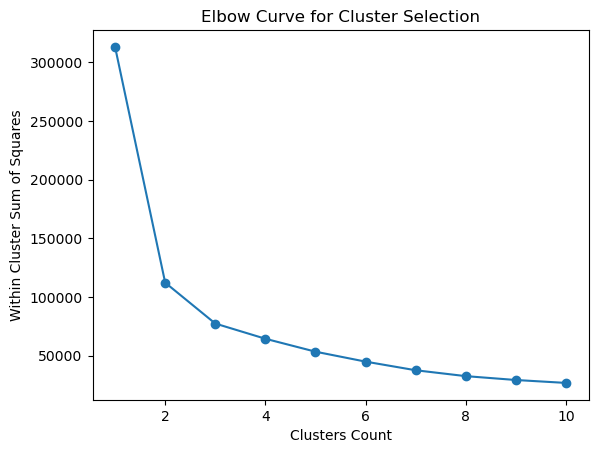

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

cluster_data = df[['age', 'bmi']]

inertia_values = []

for num in range(1, 11):
    
    k_model = KMeans(n_clusters=num, random_state=42)
    k_model.fit(cluster_data)
    
    inertia_values.append(k_model.inertia_)

# elbow curve plot 
plt.figure()

plt.plot(range(1, 11), inertia_values, marker='o')

plt.xlabel("Clusters Count")
plt.ylabel("Within Cluster Sum of Squares")
plt.title("Elbow Curve for Cluster Selection")

plt.show()

In [39]:
cluster_data = df[['age', 'bmi']]

# model
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans_model.fit_predict(cluster_data)

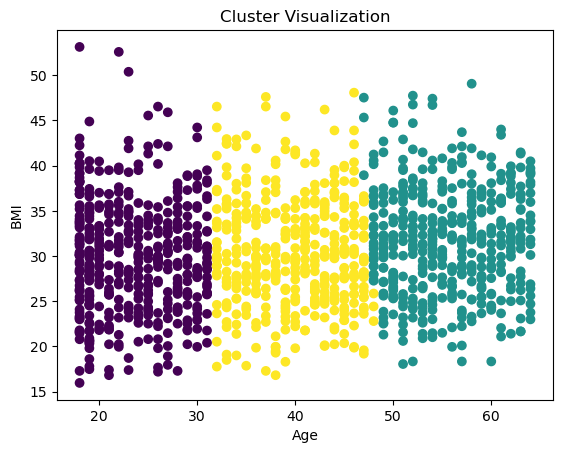

In [40]:
plt.figure()

plt.scatter(df['age'], df['bmi'], c=df['Cluster'])

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Cluster Visualization")

plt.show()